##### Setup

###### Imports

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

import numpy as np
import matplotlib.pyplot as plt

from svipy.vae import vaeEncoder, vaeDecoder, variationalAutoencoder, vqVariationalAutoencoder, autoencodingVariationalAutoencoder
from svipy.rbm import restrictedBoltzmannMachine
from svipy.model import reshape, earlyStopping

###### Load data

In [2]:
class imageOnlyDataset(torch.utils.data.Dataset):
    '''
    Class to extract only the images as do do not need labels to 
    train the generative models. 
    '''
    def __init__(self, original, index):
        self.__original = original
        self.__index = index

    @property
    def original(self):
        return self.__original

    @property
    def index(self):
        return self.__index

    def __len__(self):
        return len(self.original)

    def __getitem__(self, index):
        return self.original[index][self.index]

In [3]:
# ToTensor() scales eveything to [0, 1)
thresh = Lambda(lambda x: torch.where(ToTensor()(x) > 0.5, 1.0, 0.0))

# scatter_ to get a one-hot vector
onehot = Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))

trainData = datasets.MNIST(root="../data", train=True, download=True, transform=thresh, target_transform=onehot)
testData = datasets.MNIST(root="../data", train=False, download=True, transform=thresh, target_transform=onehot)
# trainData = datasets.MNIST(root="../data", train=True, download=True) # , transform=thresh, target_transform=onehot)

trainImageData = imageOnlyDataset(trainData, 0)  # remove the labels as we dont need them
testImageData = imageOnlyDataset(testData, 0)
print(len(trainData), len(testData), len(trainImageData), len(testImageData))

60000 10000 60000 10000


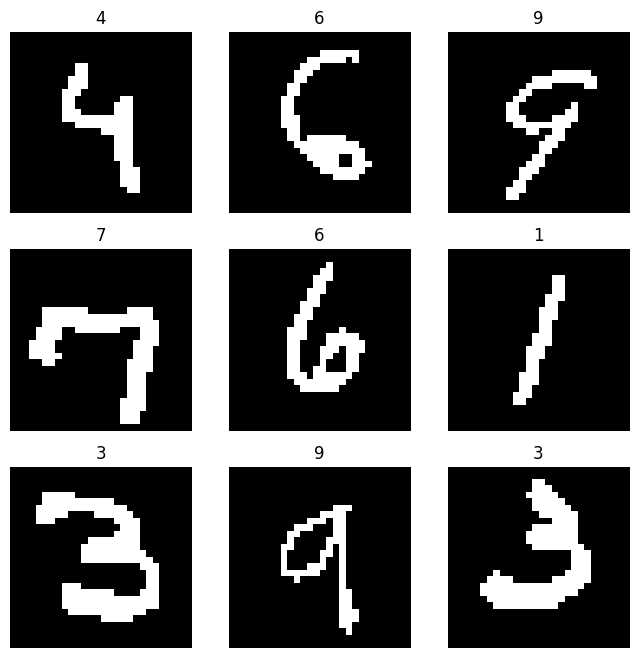

In [4]:
# show some randomly picked numbers
label_map = {k: str(k) for k in range(10)}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sidx = torch.randint(len(trainData), size=(1,)).item()
    img, label = trainData[sidx]
    figure.add_subplot(rows, cols, i)
    plt.title(label_map[torch.argmax(label, dim=0).item()])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap='gray')
plt.show()

In [5]:
# inference
def plot_latent_space(n=30, figsize=15, scale=1.0):
    # display a n*n 2D manifold of digits
    digit_size = 28
    
    figure = np.zeros((digit_size * n, digit_size * n))
    
    # linearly spaced coordinates corresponding in the 2D latent space
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
            x_decoded = model.decoder(z_sample)[0].cpu().detach()
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[i * digit_size : (i + 1) * digit_size,
                   j * digit_size : (j + 1) * digit_size] = digit

    plt.figure(figsize=(figsize, figsize))
    
    # set axis ticks corresponding to latent values
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    plt.xticks(pixel_range, np.round(grid_x, 1))
    plt.yticks(pixel_range, np.round(grid_y, 1))

    # axis labels
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    
    plt.imshow(figure, cmap="Greys_r")
    plt.show()

###### Hardware Specs

In [6]:
cudaavailable = torch.cuda.is_available()
mpsavailable = torch.backends.mps.is_available()
curr_device = torch.cuda.current_device()

device = torch.device("cuda" if cudaavailable else "mps" if mpsavailable else "cpu")
device_count = torch.cuda.device_count() 
device_name =  torch.cuda.get_device_name(0)

print(f'Cuda available: {cudaavailable}')
print(f'Current device: {curr_device}')
print(f'Device: {device}')
print(f'Device count: {device_count}')
print(f'Device name: {device_name}')

Cuda available: True
Current device: 0
Device: cuda
Device count: 1
Device name: NVIDIA GeForce GTX 970


##### MNIST

###### Variational Autoencoder

In [7]:
class mnistDecoder(vaeDecoder):
    @staticmethod
    def reconstructionLoss(x: torch.Tensor, recon: torch.Tensor) -> torch.Tensor:
        bce = torch.nn.functional.binary_cross_entropy(recon, x, reduction='none')
        return torch.mean(torch.mean(torch.flatten(bce, start_dim=1), dim=1))
        # return torch.mean(bce)

In [8]:
# build the encoder and decoder networks
hid_dim = 2

encoder = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Flatten(), # reshape([3136]), # 
                        nn.Linear(3136, hid_dim + hid_dim))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dim, 32 * 7 * 7),
                        nn.ReLU(),
                        reshape([32, 7, 7]),
                        nn.ConvTranspose2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, padding=1),
                        nn.Sigmoid())
decoder = mnistDecoder(decoder)

model = variationalAutoencoder(encoder, decoder).to(device)

In [9]:
learning_rate = 0.01
batch_size = 128
epochs = 25

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=3, minDelta=0.0001, mode='min', restoreBestWeights=True)

In [10]:
model.trainLoop(trainLoader, optimizer, epochs, 
                reportIters=100, scheduler=None,
                checkpointPath='../checkpoints/mnist_vae/',
                checkPointName='vae_2',
                validDataLoader=validLoader,
                #earlyStopper=stopper
               )

Epoch 1
-------------------------------
totalLoss: 0.267040 reconLoss: 0.267033 klLoss: 0.000007[12800/60000]
totalLoss: 0.262224 reconLoss: 0.262224 klLoss: 0.000000[25600/60000]
totalLoss: 0.262400 reconLoss: 0.262400 klLoss: 0.000000[38400/60000]
totalLoss: 0.270179 reconLoss: 0.270179 klLoss: 0.000000[51200/60000]
Validation Error: 0.264057
Epoch 2
-------------------------------
totalLoss: 0.272308 reconLoss: 0.272308 klLoss: 0.000000[12800/60000]
totalLoss: 0.267510 reconLoss: 0.267510 klLoss: 0.000000[25600/60000]
totalLoss: 0.270526 reconLoss: 0.270526 klLoss: 0.000000[38400/60000]
totalLoss: 0.273521 reconLoss: 0.273521 klLoss: 0.000000[51200/60000]
Validation Error: 0.263417
Epoch 3
-------------------------------
totalLoss: 0.259487 reconLoss: 0.259487 klLoss: 0.000000[12800/60000]
totalLoss: 0.262296 reconLoss: 0.262296 klLoss: 0.000000[25600/60000]
totalLoss: 0.257903 reconLoss: 0.257903 klLoss: 0.000000[38400/60000]
totalLoss: 0.262445 reconLoss: 0.262445 klLoss: 0.000000

In [ ]:
plot_latent_space(scale=2.0, n=30)

###### β-VAE

In [12]:
# build the encoder and decoder networks
hid_dim = 2
beta = 2.0

encoder = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Flatten(), # reshape([3136]), # 
                        nn.Linear(3136, hid_dim + hid_dim))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dim, 32 * 7 * 7),
                        nn.ReLU(),
                        reshape([32, 7, 7]),
                        nn.ConvTranspose2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, padding=1),
                        nn.Sigmoid())
decoder = mnistDecoder(decoder)

model = variationalAutoencoder(encoder, decoder, beta).to(device)

In [13]:
learning_rate = 1e-3
batch_size = 128
epochs = 25

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=3, minDelta=0.1, mode='min', restoreBestWeights=True)

In [14]:
model.trainLoop(trainLoader, optimizer, epochs, 
                reportIters=100, scheduler=None,
                checkpointPath='../checkpoints/mnist_bvae/',
                checkPointName='bvae_2_2',
                validDataLoader=validLoader,
                earlyStopper=stopper)

Epoch 1
-------------------------------
totalLoss: 0.272815 reconLoss: 0.272789 klLoss: 0.000013[12800/60000]
totalLoss: 0.276179 reconLoss: 0.276174 klLoss: 0.000002[25600/60000]
totalLoss: 0.258740 reconLoss: 0.258739 klLoss: 0.000001[38400/60000]
totalLoss: 0.264652 reconLoss: 0.264651 klLoss: 0.000000[51200/60000]
Validation Error: 0.263903
Epoch 2
-------------------------------
totalLoss: 0.263814 reconLoss: 0.263813 klLoss: 0.000000[12800/60000]
totalLoss: 0.258834 reconLoss: 0.258833 klLoss: 0.000000[25600/60000]
totalLoss: 0.262897 reconLoss: 0.262897 klLoss: 0.000000[38400/60000]
totalLoss: 0.266147 reconLoss: 0.266147 klLoss: 0.000000[51200/60000]
Validation Error: 0.263130
Epoch 3
-------------------------------
totalLoss: 0.267283 reconLoss: 0.267283 klLoss: 0.000000[12800/60000]
totalLoss: 0.268476 reconLoss: 0.268476 klLoss: 0.000000[25600/60000]
totalLoss: 0.259755 reconLoss: 0.259755 klLoss: 0.000000[38400/60000]
totalLoss: 0.269427 reconLoss: 0.269427 klLoss: 0.000000

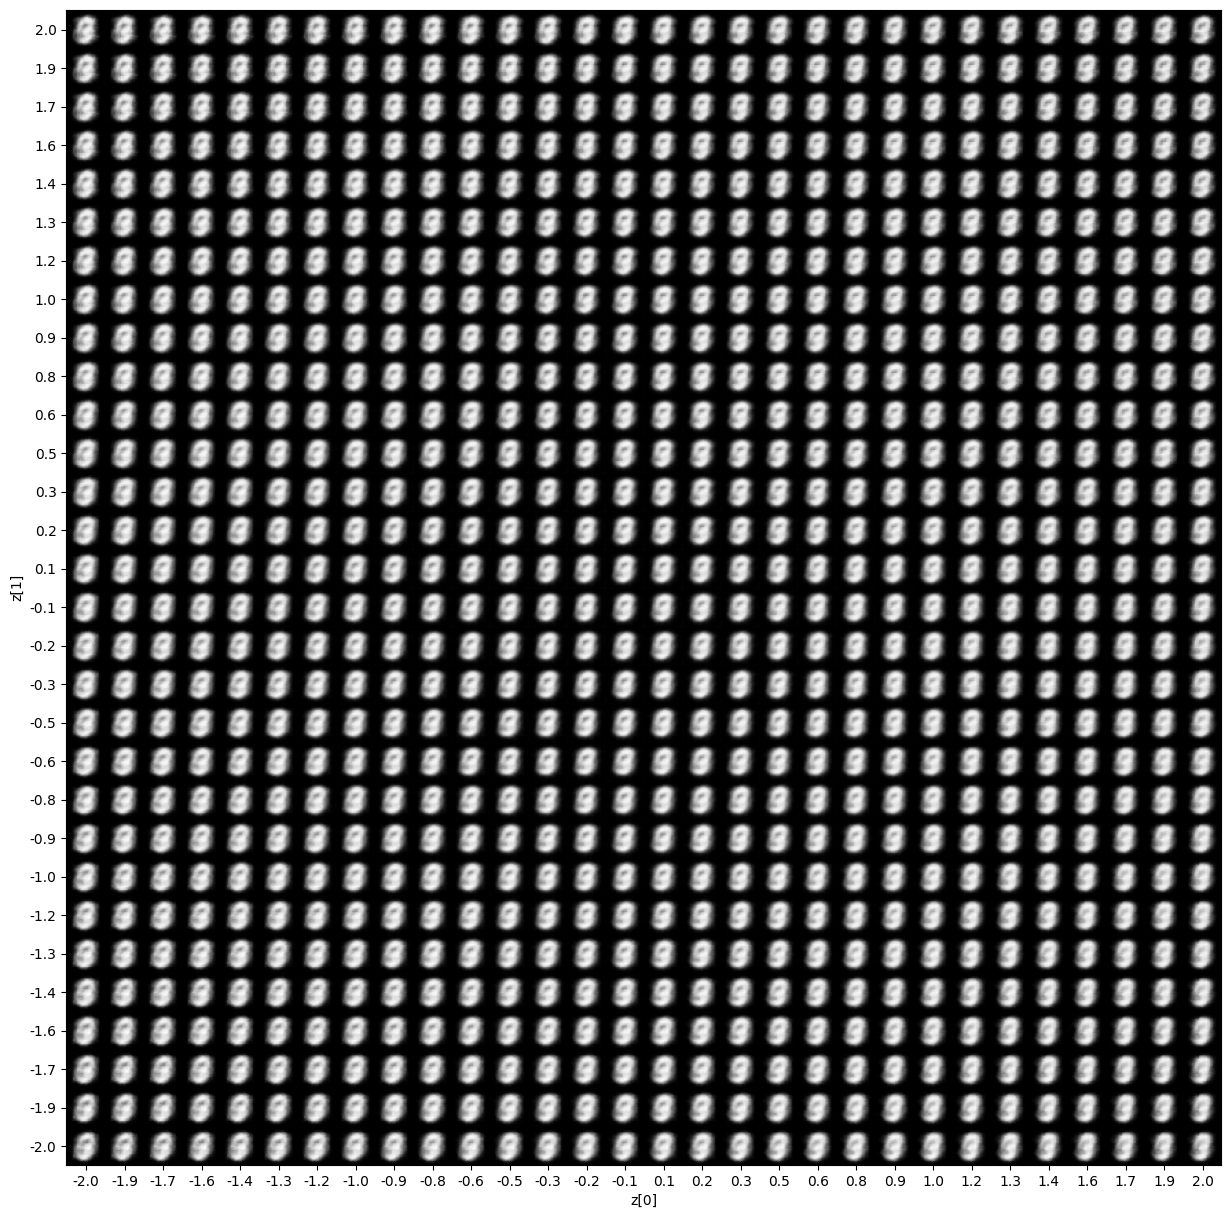

In [15]:
plot_latent_space(scale=2.0, n=30)

###### VQ-VAE

In [16]:
# build the encoder and decoder networks
hid_dim = 64
n_embeds = 10
beta = 1.
# imgs = torch.stack([trainImageData[i] for i in range(len(trainImageData))])
data_var = 0.05 # torch.var(imgs)

In [17]:
encoder = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
                        nn.ReLU())

decoder = nn.Sequential(nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.Sigmoid())

model = vqVariationalAutoencoder(encoder, decoder, nDims=hid_dim, 
                                 nEmbeddings=n_embeds, beta=beta,
                                 data_var=data_var).to(device)

In [18]:
def gradNorm(loss, params, retain_graph):
    grads = torch.autograd.grad(loss, params, retain_graph=retain_graph, allow_unused=True)
    return torch.sqrt(sum(g.pow(2).sum() for g in grads if g is not None)).item()

def compareLossScales(model, batch):
    model.train()
    encoderParams = list(model.encoder.parameters())

    losses = model.computeLoss(batch)

    reconGradNorm = gradNorm(losses['reconLoss'], encoderParams, retain_graph=True)
    vqGradNorm = gradNorm(losses['vqLoss'], encoderParams, retain_graph=False)

    print(f"recon grad norm (encoder): {reconGradNorm:.4f}")
    print(f"vq grad norm (encoder):    {vqGradNorm:.4f}")
    print(f"ratio reconGradNorm/vqGradNorm -> suggested data_var: {reconGradNorm / vqGradNorm:.4f}")

In [19]:
learning_rate = 1e-3
batch_size = 64
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=5, minDelta=0.05, mode='min', restoreBestWeights=True)

In [20]:
batch = next(iter(trainLoader)).to(device)
suggestedDataVar = compareLossScales(model, batch)

recon grad norm (encoder): 0.0427
vq grad norm (encoder):    0.2704
ratio reconGradNorm/vqGradNorm -> suggested data_var: 0.1579


In [21]:
model.trainLoop(trainLoader, optimizer, epochs, 
                reportIters=100, scheduler=None,
                checkpointPath='../checkpoints/mnist_vqvae/',
                checkPointName='vqvae_16_10',
                validDataLoader=validLoader,
                earlyStopper=stopper)

Epoch 1
-------------------------------
totalLoss: 2.499004 reconLoss: 0.060528 codeLoss: 0.644219 commLoss: 0.644219 vqLoss: 1.288437[ 6400/60000]
totalLoss: 2.540606 reconLoss: 0.059957 codeLoss: 0.670735 commLoss: 0.670735 vqLoss: 1.341470[12800/60000]
totalLoss: 2.378539 reconLoss: 0.051331 codeLoss: 0.675957 commLoss: 0.675957 vqLoss: 1.351913[19200/60000]
totalLoss: 2.367985 reconLoss: 0.048284 codeLoss: 0.701154 commLoss: 0.701154 vqLoss: 1.402307[25600/60000]
totalLoss: 2.511159 reconLoss: 0.048343 codeLoss: 0.772150 commLoss: 0.772150 vqLoss: 1.544300[32000/60000]
totalLoss: 2.635343 reconLoss: 0.050798 codeLoss: 0.809694 commLoss: 0.809694 vqLoss: 1.619388[38400/60000]
totalLoss: 2.815533 reconLoss: 0.049161 codeLoss: 0.916161 commLoss: 0.916161 vqLoss: 1.832322[44800/60000]
totalLoss: 2.373935 reconLoss: 0.046782 codeLoss: 0.719147 commLoss: 0.719147 vqLoss: 1.438294[51200/60000]
totalLoss: 2.253114 reconLoss: 0.043095 codeLoss: 0.695612 commLoss: 0.695612 vqLoss: 1.391223[5

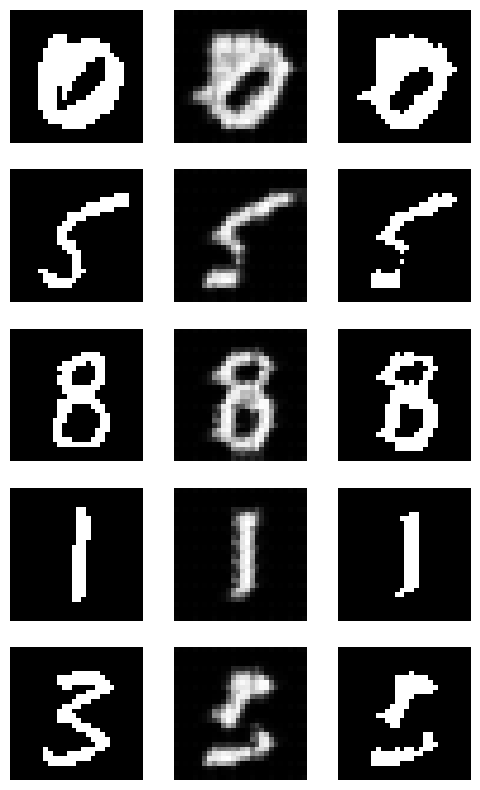

In [22]:
nCols = 3
nRows = 5

figure = plt.figure(figsize=(6, 10))
model.eval()

with torch.no_grad():
    for i in range(nRows):
        sidx = torch.randint(len(trainData), size=(1,)).item()
        img, label = trainData[sidx]
        figure.add_subplot(nRows, nCols, 3 * i + 1)
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap='gray')
        
        img = model.decode(model.encode(trainImageData[sidx].unsqueeze(0).to(device)))
        img = img.cpu().detach()
        figure.add_subplot(nRows, nCols, 3 * i + 2)
        plt.axis("off")
        plt.imshow(img.numpy().squeeze(), cmap='gray')

        figure.add_subplot(nRows, nCols, 3 * i + 3)
        plt.axis("off")
        plt.imshow(torch.where(img > 0.5, 1.0, 0.0).numpy().squeeze(), cmap='gray')

plt.show()

###### Autoencoding VAE

In [23]:
class mnistDecoder(vaeDecoder):
    @staticmethod
    def reconstructionLoss(x: torch.Tensor, recon: torch.Tensor) -> torch.Tensor:
        bce = torch.nn.functional.binary_cross_entropy(recon, x, reduction='none')
        return torch.mean(torch.sum(torch.flatten(bce, start_dim=1), dim=1))
        # return torch.mean(bce)

In [24]:
# build the encoder and decoder networks
hid_dim = 2

encoder = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Flatten(), # reshape([3136]), # 
                        nn.Linear(3136, hid_dim + hid_dim))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dim, 32 * 7 * 7),
                        nn.ReLU(),
                        reshape([32, 7, 7]),
                        nn.ConvTranspose2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, padding=1),
                        nn.Sigmoid())
decoder = mnistDecoder(decoder)

model = autoencodingVariationalAutoencoder(encoder, decoder, rho=0.98).to(device)

In [25]:
learning_rate = 1e-3
batch_size = 128
epochs = 25

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=5, minDelta=0.05, mode='min', restoreBestWeights=True)

In [26]:
model.trainLoop(trainLoader, optimizer, epochs, 
                reportIters=100, scheduler=None,
                checkpointPath='../checkpoints/mnist_avae/',
                checkPointName='avae_98',
                validDataLoader=validLoader,
                earlyStopper=stopper)

Epoch 1
-------------------------------


NameError: name 'np' is not defined

In [ ]:
plot_latent_space(scale=3.0, n=30)